# Asignación de atributos de AGEBS a la red vial VISUM-OSM

Esta notebook integra los atributos sociodemográficos y territoriales calculados para los AGEBS con la red vial completa construida a partir de VISUM y OpenStreetMap.

Los atributos de cada *link* se asignan de acuerdo con los AGEBS que intersecta su geometría. Para los *links* contenidos en más de un AGEB, las variables continuas se calculan mediante un promedio ponderado por la longitud del *link* dentro de cada polígono.

La red final conserva todos los *links* originales y permite ver lo siguiente:

- *links* con correspondencia entre VISUM y OSM
- *links* sin correspondencia OSM
- *links* cubiertos por algún AGEB
- *links* fuera de la cobertura territorial de los AGEBS

Al final se presentan la estructura del conjunto de datos resultante y distintas visualizaciones de la red, los AGEBS y los atributos asignados.

In [1]:
from pathlib import Path
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

mpl.rc("text", usetex=True)
mpl.rc("font", family="serif")

### Lectura de la red vial y los AGEBS

Cargamos la red VISUM-OSM y la capa de AGEBS.

In [ ]:
ruta_datos = Path("/Users/.../asignacion_atributos")

red = gpd.read_file(ruta_datos / "resultados_asignacion_atributos/merge_visum_osm/red_visum_atributos.shp", engine="fiona")
agebs = gpd.read_file(ruta_datos / "resultados_asignacion_atributos/zonas_agebs.gpkg", layer="zonas_agebs")

print(f"Links de la red: {len(red):,}")
print(f"AGEBS: {len(agebs):,}")

Links de la red: 593,968
AGEBS: 2,203


## Criterio de asignación de atributos zonales

Sea $j$ un *link* que intersecta $n$ AGEBS, y sea 

$$w_{ij}=\frac{L_{ij}}{\sum_{k=1}^{n}L_{kj}},$$

el peso asociado al AGEB $i$, donde $L_{ij}$ es la longitud del *link* $j$ dentro del AGEB $i$. Entonces, los atributos continuos $X$ (densidad de población, densidad de empleo y distancia al centro de Guadalajara) de cada *link* los asignamos a partir de un promedio ponderado por la longitud contenida en cada AGEB, es decir, 

$$X_j=\sum_{i=1}^{n} w_{ij}X_i.$$

Además, asignamos como AGEB principal aquel con la mayor longitud intersectada. Los *links* de longitud cero heredaron directamente los atributos del AGEB donde se localiza su geometría, mientras que los *links* sin intersección con ningún AGEB fueron excluidos del conjunto de *clustering* por falta de cobertura.

### Preparación de la red

Conservamos una copia completa de la red y asignamos un identificador interno único a cada *link*. Los *links* sin correspondencia entre VISUM y OSM se identifican mediante el valor `-1` en la columna `cluster`. Los demás *links* se reproyectan al sistema métrico de los AGEBS para calcular sus longitudes e intersecciones.

In [4]:
red_completa = red.copy()
red_completa["link_id"] = np.arange(len(red_completa))
red_completa["cluster"] = np.nan

red_completa.loc[red_completa["con_osm"] != 1, "cluster"] = -1

red_clustering = red_completa.loc[red_completa["cluster"].isna()].copy()
red_clustering = red_clustering.to_crs(agebs.crs)
red_clustering["longitud_total_m"] = red_clustering.geometry.length

### Clasificación de los links según su longitud

Los links con correspondencia OSM se separan en dos grupos:

1. **Links con longitud positiva:** sus atributos zonales se calcularán mediante la proporción de longitud contenida dentro de cada AGEB.

2. **Links con longitud cero:** al tener longitud cero, su geometría se representará mediante un punto y los atributos se asignarán directamente desde el AGEB que intersecte dicho punto.

In [6]:
red_longitud_positiva = red_clustering.loc[red_clustering["longitud_total_m"] > 0].copy()
red_longitud_cero = red_clustering.loc[red_clustering["longitud_total_m"] == 0].copy()
red_longitud_cero["geometry"] = red_longitud_cero.geometry.apply(lambda geometria: geometria.interpolate(0))

print(f"Links con longitud positiva: {len(red_longitud_positiva):,}")
print(f"Links con longitud cero: {len(red_longitud_cero):,}")

Links con longitud positiva: 447,496
Links con longitud cero: 9,631


### Identificación de AGEBS candidatos

Realizamos una unión espacial entre los *links* con longitud positiva y los polígonos de AGEBS. Un mismo *link* puede aparecer varias veces cuando intersecta más de un AGEB. Estas correspondencias constituyen los candidatos sobre los que posteriormente se calculará la longitud exacta de intersección.

In [7]:
columnas_agebs = ["clave_ageb", "nombre_municipio", "tipo_ageb", "densidad_poblacion_km2", "densidad_empleo_km2", "distancia_centro_gdl_km", "geometry"]
candidatos = gpd.sjoin(red_longitud_positiva[["link_id", "longitud_total_m", "geometry"]], agebs[columnas_agebs], how="left", predicate="intersects")

print(f"Correspondencias link-AGEB candidatas: {candidatos['index_right'].notna().sum():,}")
print(f"Links con al menos un AGEB candidato: {candidatos.loc[candidatos['index_right'].notna(), 'link_id'].nunique():,}")
print(f"Links sin ningún AGEB candidato: {candidatos.loc[candidatos['index_right'].isna(), 'link_id'].nunique():,}")

Correspondencias link-AGEB candidatas: 503,913
Links con al menos un AGEB candidato: 446,986
Links sin ningún AGEB candidato: 510


### Cálculo de longitud

Para cada correspondencia candidata calculamos la intersección geométrica entre el *link* y el polígono del AGEB. La longitud de esta geometría representa los metros del *link* contenidos dentro del AGEB correspondiente. No consideramos las intersecciones con longitud cero, pues son puntos que tocan bordes o vértices y no representan ningún grado de cobertura del *link*.

In [8]:
intersecciones = candidatos.dropna(subset=["index_right"]).reset_index(drop=True).copy()
indices_agebs = intersecciones["index_right"].astype(int).to_numpy()
intersecciones["geometry_ageb"] = gpd.GeoSeries(agebs.geometry.iloc[indices_agebs].array, index=intersecciones.index, crs=agebs.crs)
intersecciones["geometry_interseccion"] = intersecciones.geometry.intersection(intersecciones["geometry_ageb"])
intersecciones["longitud_en_ageb_m"] = intersecciones["geometry_interseccion"].length
intersecciones = intersecciones.loc[intersecciones["longitud_en_ageb_m"] > 0].copy()

print(f"Intersecciones con longitud positiva: {len(intersecciones):,}")
print(f"Links con cobertura efectiva de AGEBS: {intersecciones['link_id'].nunique():,}")

Intersecciones con longitud positiva: 503,913
Links con cobertura efectiva de AGEBS: 446,986


### Cálculo de los pesos por longitud

Para cada *link* sumamos la longitud contenida en todos los AGEBS que intersecta. Después calculamos la proporción correspondiente a cada AGEB:

$$w_{ij}=\frac{L_{ij}}{L_j^{\mathrm{cubierta}}},$$

donde $L_{ij}$ es la longitud del *link* $j$ dentro del AGEB $i$, y $L_j^{\mathrm{cubierta}}$ es la longitud total del *link* cubierta por los AGEBS.

Estos pesos se los usaremos calcular la contribución de cada AGEB a la densidad de población, la densidad de empleo y la distancia al centro de Guadalajara.

In [11]:
intersecciones["longitud_cubierta_m"] = intersecciones.groupby("link_id")["longitud_en_ageb_m"].transform("sum")
intersecciones["peso_longitud"] = intersecciones["longitud_en_ageb_m"] / intersecciones["longitud_cubierta_m"]

intersecciones["densidad_poblacion_pond"] = intersecciones["densidad_poblacion_km2"] * intersecciones["peso_longitud"]
intersecciones["densidad_empleo_pond"] = intersecciones["densidad_empleo_km2"] * intersecciones["peso_longitud"]
intersecciones["distancia_centro_pond"] = intersecciones["distancia_centro_gdl_km"] * intersecciones["peso_longitud"]

### Consolidación de los atributos por link

Las correspondencias link-AGEB se agregan para obtener una sola observación por link. Las variables continuas se calculan mediante la suma de sus contribuciones ponderadas con los pesos obtenidos anteriormente. Además, se identifica como AGEB principal aquel que contiene la mayor longitud del link.

Para cada *link*

- la longitud total cubierta por AGEBS
- el número de AGEBS intersectados
- la proporción contenida en el AGEB principal
- la proporción total del link cubierta por la capa de AGEBS

In [ ]:
atributos_ponderados = intersecciones.groupby("link_id").agg(densidad_poblacion_km2=("densidad_poblacion_pond", "sum"), densidad_empleo_km2=("densidad_empleo_pond", "sum"), distancia_centro_gdl_km=("distancia_centro_pond", "sum"), longitud_cubierta_m=("longitud_en_ageb_m", "sum"), numero_agebs=("clave_ageb", "nunique")).reset_index()
ageb_principal = intersecciones.loc[intersecciones.groupby("link_id")["longitud_en_ageb_m"].idxmax(), ["link_id", "clave_ageb", "nombre_municipio", "tipo_ageb", "peso_longitud"]].copy()

ageb_principal = ageb_principal.rename(columns={"clave_ageb": "clave_ageb_principal", "nombre_municipio": "municipio_principal", "tipo_ageb": "tipo_ageb_principal", "peso_longitud": "proporcion_ageb_principal"})
atributos_ponderados = atributos_ponderados.merge(ageb_principal, on="link_id", how="left", validate="one_to_one")

longitudes_links = red_longitud_positiva.set_index("link_id")["longitud_total_m"]
atributos_ponderados["proporcion_link_cubierta"] = atributos_ponderados["longitud_cubierta_m"] / atributos_ponderados["link_id"].map(longitudes_links)

### Asignación de atributos a los links con longitud cero

Para los *links* con longitud cero, los covertimos a punto, y los asignamos directamente los atributos del AGEB que intersecta este punto. Si uno coincide con el límite de varios AGEBS, se conserva una sola correspondencia para mantener una observación por *link*.

In [15]:
atributos_longitud_cero = gpd.sjoin(red_longitud_cero[["link_id", "geometry"]], agebs[columnas_agebs], how="left", predicate="intersects")
atributos_longitud_cero = atributos_longitud_cero.sort_values(["link_id", "index_right"]).drop_duplicates(subset="link_id", keep="first")

atributos_longitud_cero["clave_ageb_principal"] = atributos_longitud_cero["clave_ageb"]
atributos_longitud_cero["municipio_principal"] = atributos_longitud_cero["nombre_municipio"]
atributos_longitud_cero["tipo_ageb_principal"] = atributos_longitud_cero["tipo_ageb"]
atributos_longitud_cero["longitud_cubierta_m"] = 0.0
atributos_longitud_cero["numero_agebs"] = atributos_longitud_cero["index_right"].notna().astype(int)
atributos_longitud_cero["proporcion_ageb_principal"] = atributos_longitud_cero["index_right"].notna().astype(float)
atributos_longitud_cero["proporcion_link_cubierta"] = atributos_longitud_cero["index_right"].notna().astype(float)

columnas_resultado_agebs = ["link_id", "densidad_poblacion_km2", "densidad_empleo_km2", "distancia_centro_gdl_km", "longitud_cubierta_m", "numero_agebs", "clave_ageb_principal", "municipio_principal", "tipo_ageb_principal", "proporcion_ageb_principal", "proporcion_link_cubierta"]
atributos_longitud_cero = atributos_longitud_cero[columnas_resultado_agebs].copy()

print(f"Links de longitud cero procesados: {len(atributos_longitud_cero):,}")
print(f"Links de longitud cero con AGEB: {atributos_longitud_cero['clave_ageb_principal'].notna().sum():,}")
print(f"Links de longitud cero sin AGEB: {atributos_longitud_cero['clave_ageb_principal'].isna().sum():,}")

Links de longitud cero procesados: 9,631
Links de longitud cero con AGEB: 9,630
Links de longitud cero sin AGEB: 1


### Integración de los atributos territoriales en la red completa

Unificamos los resultados obtenidos para los *links* con longitud positiva y los *links* con longitud cero. 

La tabla la incorporamos posteriormente a la red mediante con el identificador `link_id`. De esta forma logramos quedarnos con los *links* originales, pero también con aquellos sin correspondencia OSM o sin cobertura de AGEBS.

In [16]:
atributos_agebs_links = pd.concat([atributos_ponderados[columnas_resultado_agebs], atributos_longitud_cero], ignore_index=True)

atributos_agebs_links["proporcion_ageb_principal"] = atributos_agebs_links["proporcion_ageb_principal"].clip(0, 1)
atributos_agebs_links["proporcion_link_cubierta"] = atributos_agebs_links["proporcion_link_cubierta"].clip(0, 1)

red_final = red_completa.merge(atributos_agebs_links, on="link_id", how="left", validate="one_to_one")
red_final = gpd.GeoDataFrame(red_final, geometry="geometry", crs=red_completa.crs)

print(f"Links en la red final: {len(red_final):,}")
print(f"Links con atributos de AGEBS: {red_final['clave_ageb_principal'].notna().sum():,}")
print(f"Links sin atributos de AGEBS: {red_final['clave_ageb_principal'].isna().sum():,}")

Links en la red final: 593,968
Links con atributos de AGEBS: 456,616
Links sin atributos de AGEBS: 137,352


### Identificación de links excluidos del clustering

Aunque la red que acabamos de generar tiene todos los *links* originales, no todos tienen la información completa para el análisis. Para esto generamos dos códigos de exclusión en la columna `cluster`:

- `-1` para los links sin correspondencia entre VISUM y OSM;
- `-2` para los links que sí tienen correspondencia OSM–VISUM, pero no intersectan ningún AGEB.

Mientras que los *links* con celdas vacías en esta misma columna cuentan con atributos viales y territoriales, por lo que constituyen el conjunto disponible para el análisis de clustering.

In [17]:
mascara_sin_ageb = red_final["cluster"].isna() & red_final["clave_ageb_principal"].isna()
red_final.loc[mascara_sin_ageb, "cluster"] = -2

print(f"Links disponibles para clustering: {red_final['cluster'].isna().sum():,}")
print(f"Links sin correspondencia OSM-VISUM: {(red_final['cluster'] == -1).sum():,}")
print(f"Links sin cobertura de AGEBS: {(red_final['cluster'] == -2).sum():,}")

Links disponibles para clustering: 456,616
Links sin correspondencia OSM-VISUM: 136,841
Links sin cobertura de AGEBS: 511


### Preparación de las variables numéricas

Para evitar valores, asignamos cero a los *links* con `cluster = -1` o `cluster = -2`. Estos deben interpretarse únicamente como etiquetas de exclusión. Los *links* para el clustering mantienen sus atributos originales.

In [18]:
columnas_cluster = ["cap_final", "carr_final", "velprom_fi", "vel_final", "densidad_poblacion_km2", "densidad_empleo_km2", "distancia_centro_gdl_km"]
columnas_cobertura = [ "longitud_cubierta_m", "numero_agebs", "proporcion_ageb_principal", "proporcion_link_cubierta"]

mascara_fuera_cluster = red_final["cluster"].notna()

red_final.loc[mascara_fuera_cluster, columnas_cluster] = 0
red_final.loc[mascara_fuera_cluster, columnas_cobertura] = 0

## Conjunto final

La tabla final conserva los identificadores originales de la red, los atributos viales, los atributos territoriales derivados de los AGEBS, los indicadores de cobertura espacial y la geometría de cada *link*.

In [22]:
columnas_red_final = ["No", "FromNodeNo", "ToNodeNo", "TypeNo", "TSysSet", "Length", "U", "V", "KEY", "HIGHWAY", "cap_final", "carr_final", "velprom_fi", "vel_final", "con_osm", "clave_ageb_principal", "municipio_principal", "tipo_ageb_principal", "densidad_poblacion_km2", "densidad_empleo_km2", "distancia_centro_gdl_km", "numero_agebs", "proporcion_ageb_principal", "proporcion_link_cubierta", "cluster", "geometry"]
red_resultado = red_final[columnas_red_final].copy()

red_resultado = red_resultado.rename(columns={"FromNodeNo": "from_node", "ToNodeNo": "to_node", "clave_ageb_principal": "ageb_prin", "municipio_principal": "municipio", "tipo_ageb_principal": "tipo_ageb", "densidad_poblacion_km2": "dens_pob", "densidad_empleo_km2": "dens_emp", "distancia_centro_gdl_km": "dist_gdl", "numero_agebs": "n_agebs", "proporcion_ageb_principal": "prop_ageb", "proporcion_link_cubierta": "prop_cub"})
red_resultado = gpd.GeoDataFrame(red_resultado, geometry="geometry", crs=red_final.crs)

print(f"Filas del resultado final: {len(red_resultado):,}")
print(f"Columnas del resultado final: {len(red_resultado.columns):,}")
print(f"CRS del resultado final: {red_resultado.crs}")

display(red_resultado.head())

Filas del resultado final: 593,968
Columnas del resultado final: 26
CRS del resultado final: EPSG:4326


,No,from_node,to_node,TypeNo,TSysSet,Length,U,V,KEY,HIGHWAY,cap_final,carr_final,velprom_fi,vel_final,con_osm,ageb_prin,municipio,tipo_ageb,dens_pob,dens_emp,dist_gdl,n_agebs,prop_ageb,prop_cub,cluster,geometry
0,1,1,103492,0,"B,C",4.827825,267537966,7306651630,0,motorway,4000.0,2.0,24.000000,30.0,1,1410100011041,Tonalá,urbano,9180.769566,2644.232296,9.739104,13.0,0.219334,1.0,NaN,"LINESTRING (-103.2463 20.6161, -103.2473 20.61..."
1,1,103492,1,0,None,0.000000,0,0,0,None,0.0,0.0,0.000000,0.0,0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.000000,0.0,-1.0,"LINESTRING (-103.2905 20.6279, -103.2894 20.62..."
2,2,1,15708,0,"B,C",0.146029,267537966,5837556433,0,motorway_link,4000.0,2.0,23.999956,30.0,1,141010001097A,Tonalá,urbano,4992.329392,7430.880132,11.584469,1.0,1.000000,1.0,NaN,"LINESTRING (-103.2463 20.6161, -103.2465 20.61..."
3,2,15708,1,0,None,0.000000,0,0,0,None,0.0,0.0,0.000000,0.0,0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.000000,0.0,-1.0,"LINESTRING (-103.2477 20.6163, -103.2475 20.61..."
4,3,2,3,0,"B,C",0.520237,267538751,273140976,0,motorway,2500.0,1.0,53.999923,80.0,1,141240090,Zapotlanejo,rural,92.922836,8.309218,30.311418,1.0,1.000000,1.0,NaN,"LINESTRING (-103.1364 20.6056, -103.1343 20.60..."


## Visualización

In [24]:
agebs_plot = agebs.to_crs(agebs.crs)
red_plot = red_resultado.to_crs(agebs.crs)

red_disponible = red_plot.loc[red_plot["cluster"].isna()].copy()
red_sin_osm = red_plot.loc[red_plot["cluster"] == -1].copy()
red_sin_ageb = red_plot.loc[red_plot["cluster"] == -2].copy()

Se presentan tres figuras:

1. Cobertura general de la red respecto a los AGEBS

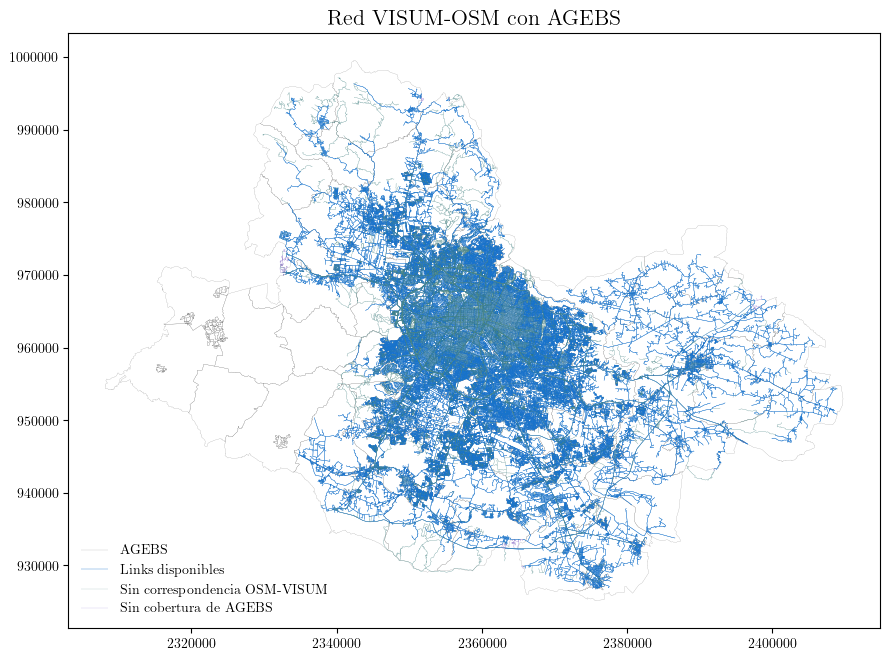

In [47]:
fig, ax = plt.subplots(figsize=(9, 9))

agebs_plot.boundary.plot(ax=ax, linewidth=0.09, color=(0.25, 0.25, 0.25), label="AGEBS")
red_disponible.plot(ax=ax, linewidth=0.25, color=(0.09, 0.45, 0.8), label="Links disponibles")
red_sin_osm.plot(ax=ax, linewidth=0.25, alpha=0.75, color=(0.32, 0.55, 0.55), label="Sin correspondencia OSM-VISUM")
red_sin_ageb.plot(ax=ax, linewidth=0.25, alpha=0.75, color=(0.54, 0.41, 0.8), label="Sin cobertura de AGEBS")

ax.set_title(r"Red VISUM-OSM con AGEBS", fontsize=16)
ax.legend(loc="lower left", frameon=False, fontsize=10)
ax.set_aspect("equal")
ax.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()

2. Atributos viales en los AGEBS:
   - capacidad vial
   - número de carriles
   - velocidad promedio
   - límite de velocidad

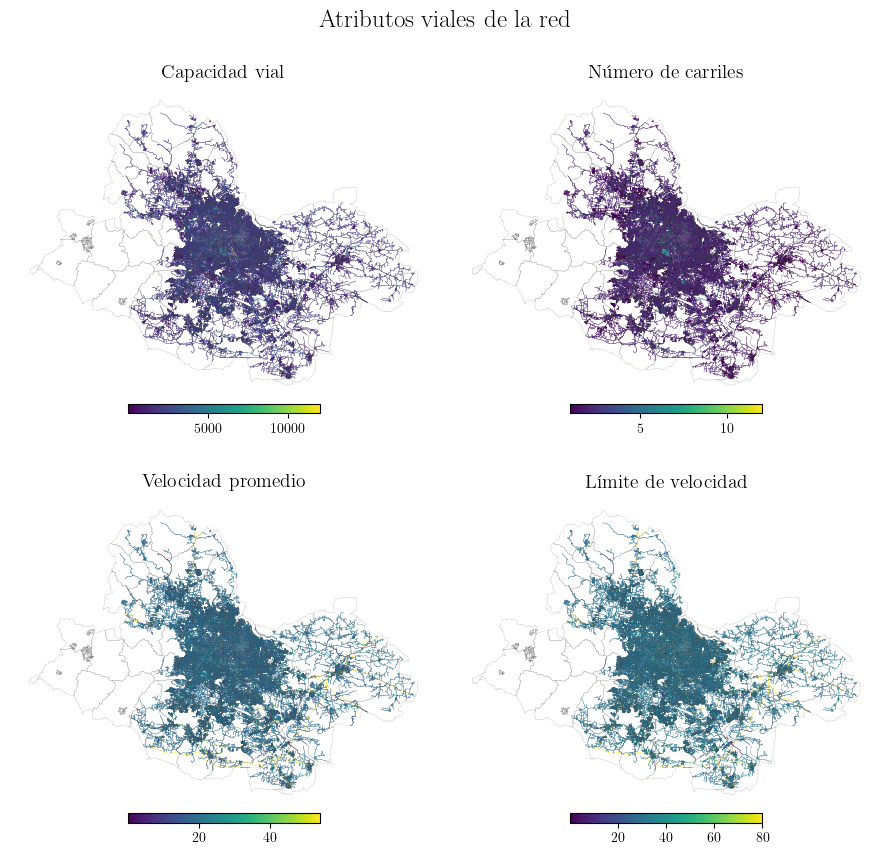

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
mapas_viales = [("cap_final", r"Capacidad vial"), ("carr_final", r"Número de carriles"), ("velprom_fi", r"Velocidad promedio"), ("vel_final", r"Límite de velocidad")]

for ax, (columna, titulo) in zip(axes.ravel(), mapas_viales):
    red_disponible.plot(column=columna, ax=ax, linewidth=0.20, legend=True, cmap="viridis", legend_kwds={"shrink": 0.45, "orientation": "horizontal", "pad": 0.01})
    agebs_plot.boundary.plot(ax=ax, linewidth=0.09, color=(0.25, 0.25, 0.25))
    ax.set_title(titulo, fontsize=14)
    ax.set_aspect("equal")
    ax.set_axis_off()

fig.suptitle(r"Atributos viales de la red", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

3. Atributos territoriales en los AGEBS
   - densidad de población
   - densidad de empleo
   - distancia al centro de Guadalajara

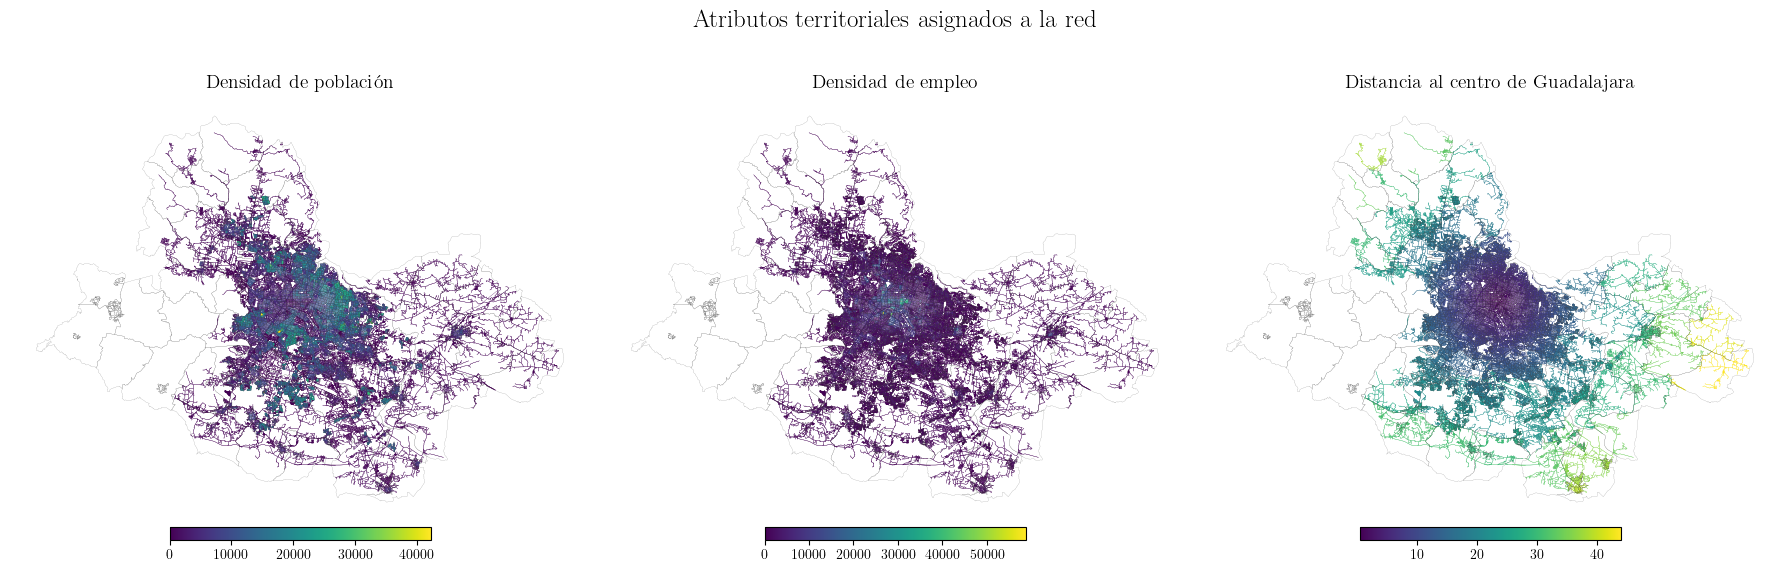

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
mapas_territoriales = [("dens_pob", r"Densidad de población"), ("dens_emp", r"Densidad de empleo"), ("dist_gdl", r"Distancia al centro de Guadalajara")]

for ax, (columna, titulo) in zip(axes, mapas_territoriales):
    red_disponible.plot(column=columna, ax=ax, linewidth=0.20, legend=True, cmap="viridis", legend_kwds={"shrink": 0.45, "orientation": "horizontal", "pad": 0.01})
    agebs_plot.boundary.plot(ax=ax, linewidth=0.09, color=(0.25, 0.25, 0.25))
    ax.set_title(titulo, fontsize=14)
    ax.set_aspect("equal")
    ax.set_axis_off()

fig.suptitle(r"Atributos territoriales asignados a la red", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()